# 🏥 Healthcare Risk Prediction

This script applies 4 advanced ML models on the Healthcare dataset:
1. Random Forest Classifier
2. K-Nearest Neighbours (KNN)
3. Decision Tree Classifier
4. Naive Bayes (GaussianNB)
Each model is followed by rich data visualisations (confusion matrix,
ROC curve, feature importance / probability distribution) as shown in
ML_Learning.ipynb.



In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# "scikit-learn", provides simple and efficient tools for data mining and data analysis. 
# It is built on top of NumPy, SciPy, and matplotlib, and is widely used for various machine learning tasks such as 
# classification, regression, clustering, and dimensionality reduction.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder #label encoding for categorical variables, standardization for numerical features
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
    , roc_curve, auc, ConfusionMatrixDisplay
)
#auc is a performance measurement for classification problems at various threshold settings.
#ROC is a probability curve and AUC represents the degree or measure of separability.

# 1. LOAD & MERGE DATASETS

In [39]:
patients    = pd.read_csv('Patients.csv')
diagnosis   = pd.read_csv('Diagnoses.csv')
outcomes    = pd.read_csv('Outcomes.csv')
labs        = pd.read_csv('Labs.csv')
doctors     = pd.read_csv('Doctors.csv')
departments = pd.read_csv('Departments.csv')

# Merge datasets to create a comprehensive patient dataset
patients = patients.merge(diagnosis[['DiagnosisID', 'DiagnosisName']], on='DiagnosisID')
patients = patients.merge(outcomes,  on='OutcomeID')
patients = patients.merge(
    doctors[['DoctorID', 'DoctorName', 'Specialty', 'ExperienceYears']],
    on='DoctorID'
)

print(f"✅ Merged dataset shape : {patients.shape}")
print(patients.head(3))

✅ Merged dataset shape : (1000, 15)
   PatientID     Name  Age Gender  DiagnosisID  DoctorID AdmissionDate  \
0          1  Sneha 1   69      F            5         3    2025-01-27   
1          2  Rahul 2   60      M            7        14    2025-02-10   
2          3  Vikas 3   61      F            4        13    2025-02-20   

  DischargeDate  OutcomeID  TreatmentCost DiagnosisName OutcomeName  \
0    2025-02-05          3         7220.0        Stroke    Deceased   
1    2025-02-19          1         9193.0        Cancer   Recovered   
2    2025-03-02          1         6082.0        Asthma   Recovered   

          DoctorName      Specialty  ExperienceYears  
0    Dr. Rahul Verma    Neurologist              3.0  
1  Dr. Pooja Agarwal     Oncologist              5.0  
2    Dr. Nitin Gupta  Pulmonologist             20.0  


# 2. FEATURE ENGINEERING 

In [40]:
# Date features → Length of Stay
# mixed, allows flexible parsing, i.e. handles different date representations in the 'AdmissionDate' column without throwing errors.
# dt accessor allows us to access datetime properties of the 'AdmissionDate' and 'DischargeDate' columns, and .days extracts the number of days as an integer.
patients['AdmissionDate'] = pd.to_datetime(patients['AdmissionDate'], format='mixed') 
patients['DischargeDate']  = pd.to_datetime(patients['DischargeDate'],  format= 'mixed')
patients['LengthOfStay']   = (patients['DischargeDate'] - patients['AdmissionDate']).dt.days

# Binary outcome encoding (Recovered=0, Deceased/Complicated=1)
patients['OutcomeEncoded'] = patients['OutcomeName'].map(
    {'Recovered': 0, 'Deceased': 1, 'Complicated': 1}
)

# HighRisk flag, 
# the below code means that if any of the conditions (age > 65, length of stay > 7, or outcome is Complicated/Deceased) are true, then HighRisk is set to 1, otherwise it is set to 0.
patients['HighRisk'] = np.where(
    (patients['Age'] > 65) |
    (patients['LengthOfStay'] > 7) |
    (patients['OutcomeName'].isin(['Complicated', 'Deceased'])), 
    1, 0
)
# patients['HighRisk'] = np.where(
#     (patients['Age'] > 65) |
#     (patients['LengthOfStay'] > 7) |
#     ((patients['OutcomeID']==3) & (patients['OutcomeID']==2)), 
#     1, 0
# )

# Abnormal lab count per patient
abnormal_conditions = {
    'Cholesterol':    lambda x: x > 200 or x < 100,
    'Blood Sugar':    lambda x: x > 140 or x < 70,
    'Blood Pressure': lambda x: x > 120 or x < 60,
    'Hemoglobin':     lambda x: x < 12.0,
    'Creatinine':     lambda x: x > 1.2,
    'Vitamin D':      lambda x: x < 20,
}

def count_abnormal_labs(patient_id):
    patient_labs = labs[labs['PatientID'] == patient_id]
    count = 0
    for test_name, condition in abnormal_conditions.items():
        test_results = patient_labs[patient_labs['TestName'] == test_name]
        count += test_results['Result'].apply(condition).sum()
    return count

print("⏳ Counting abnormal lab results per patient (takes a moment)…")
patients['AbnormalLabCount'] = patients['PatientID'].apply(count_abnormal_labs)

# Encode Gender (M=1, F=0) using LabelEncoder, which converts categorical text data into numerical labels.
patients['GenderEncoded'] = LabelEncoder().fit_transform(patients['Gender'])
# 1 is for Male and 0 is for Female

# Encode DiagnosisName
patients['DiagnosisEncoded'] = LabelEncoder().fit_transform(patients['DiagnosisName'])

print(f"\n✅ High-Risk patients : {patients['HighRisk'].sum()} / {len(patients)}")
print(f"   Avg Abnormal Labs : {patients['AbnormalLabCount'].mean():.2f}")
print(patients[['Age', 'GenderEncoded', 'DiagnosisEncoded', 'LengthOfStay', 'TreatmentCost', 'AbnormalLabCount',
                 'OutcomeName', 'HighRisk']].head(6).to_string())


⏳ Counting abnormal lab results per patient (takes a moment)…

✅ High-Risk patients : 806 / 1000
   Avg Abnormal Labs : 4.11
   Age  GenderEncoded  DiagnosisEncoded  LengthOfStay  TreatmentCost  AbnormalLabCount  OutcomeName  HighRisk
0   69              0                 9             9         7220.0               2.0     Deceased         1
1   60              1                 3             9         9193.0              11.0    Recovered         1
2   61              0                 1            10         6082.0               3.0    Recovered         1
3   80              1                 5             6         2268.0               8.0  Complicated         1
4   38              0                 6             5         5956.0               4.0    Recovered         0
5   43              0                 2             5         2521.0               1.0    Recovered         0


# 3. TRAIN / TEST SPLIT  
(using enriched feature set)

In [41]:
# Extended feature set (4 original + 2 new encoded features)
FEATURES = [
    'Age', 'LengthOfStay', 'TreatmentCost', 'AbnormalLabCount',
    'GenderEncoded', 'DiagnosisEncoded'
]
TARGET = 'HighRisk'    # Multi-class: 0 = Low Risk, 1 = High Risk

X = patients[FEATURES]
y = patients[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
#stratify=y ensures that the proportion of classes in the target variable is maintained in both the training and test sets, which is important for imbalanced datasets.

# Scale features (required for KNN & Naive Bayes; good practice for all)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
# fit_transform computes the mean and standard deviation from the training data and applies the transformation, while 
# transform uses the already computed mean and standard deviation to scale the test data without altering the parameters.

print(f"✅ Training set : {X_train.shape}  |  Test set : {X_test.shape}")
print(f"    Target distribution (train): {dict(pd.Series(y_train).value_counts())}")
print(f"    Target distribution (test): {dict(pd.Series(y_test).value_counts())}")


✅ Training set : (800, 6)  |  Test set : (200, 6)
    Target distribution (train): {1: 645, 0: 155}
    Target distribution (test): {1: 161, 0: 39}


HELPER FUNCTIONS  (shared visualisation utilities)

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS  (shared visualisation utilities)
# ─────────────────────────────────────────────────────────────────────────────

# CONFUSION MATRIX
def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low Risk', 'High Risk']
    )
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
        
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix – {model_name}", fontsize=13, fontweight='bold')

# ROC CURVE - it plots the Receiver Operating Characteristic (ROC) curve for a given set of true labels (y_true) and predicted probabilities (y_prob) for a binary classification model. 
# The ROC curve illustrates the performance of the model across different classification thresholds, 
# and the Area Under the Curve (AUC) is calculated to summarize the overall performance of the model.
def plot_roc_curve(y_true, y_prob, model_name, ax=None):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    # fpr = False Positive Rate, tpr = True Positive Rate
    roc_auc = auc(fpr, tpr)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
    ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Random (AUC = 0.50)') 
    # here AUC is .50 because a random classifier would have an equal chance of being correct or incorrect, resulting in a 50% true positive rate and a 50% false positive rate.
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve – {model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right') 
    #legend is a box that displays the labels for the different lines in the plot, and loc='lower right' positions the legend in the lower right corner of the plot.
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    return roc_auc

# METRICS SUMMARY
def print_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) * 100
    print(f"\n📊 {model_name}")
    print(f"   Accuracy : {acc:.2f}%")
    print(classification_report(y_true, y_pred,
                                 target_names=['Low Risk', 'High Risk'],
                                 digits=3))
    return acc

# MODEL 1 ▸ RANDOM FOREST CLASSIFIER


📊 Random Forest
   Accuracy : 73.50%
              precision    recall  f1-score   support

    Low Risk      0.403     0.744     0.523        39
   High Risk      0.922     0.733     0.817       161

    accuracy                          0.735       200
   macro avg      0.662     0.738     0.670       200
weighted avg      0.821     0.735     0.759       200



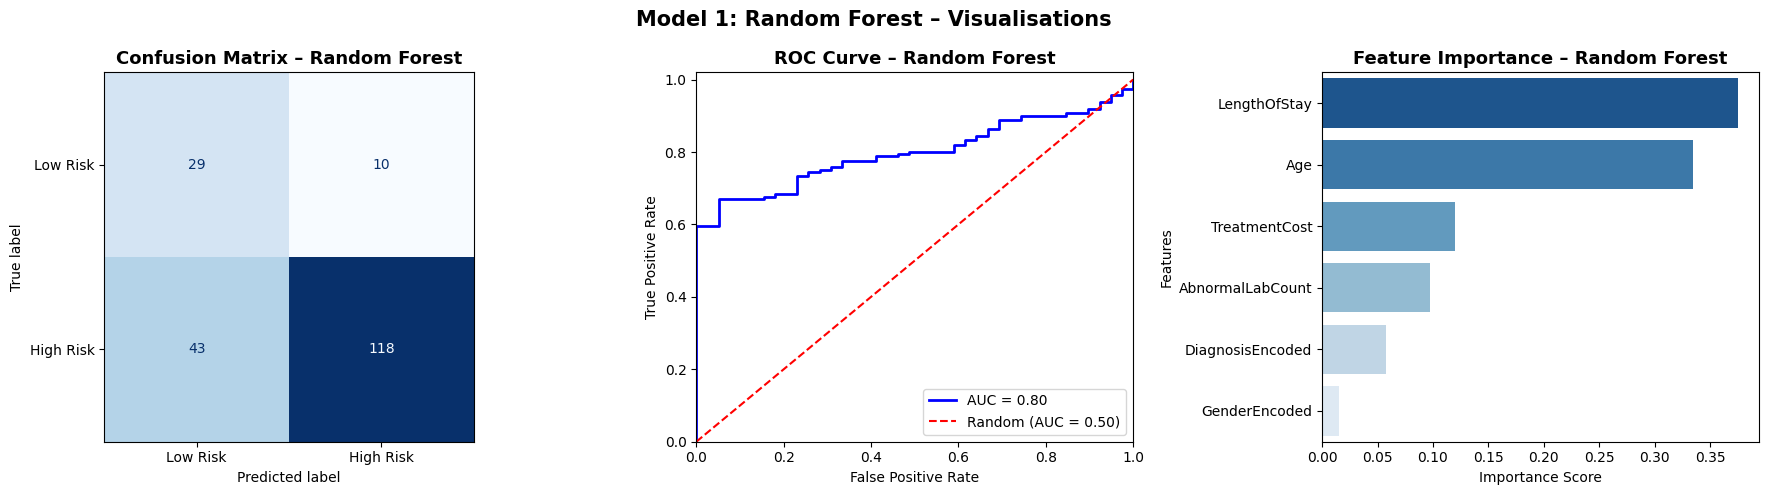

💾 Saved → model1_random_forest.png


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=250, # this is the number of trees in the forest, which helps to reduce overfitting and improve generalization.
    # more the
    max_depth=8,
    class_weight='balanced',
    random_state = 50 #this ensures that the results are reproducible by controlling the randomness in the model training process.
    # more the random_state number, more the reproducibility (but also more the time taken to train the model due to less randomness in tree construction
)
rf_model.fit(X_train, y_train)          # Raw (unscaled) features for RF
rf_pred  = rf_model.predict(X_test)
rf_prob  = rf_model.predict_proba(X_test)[:, 1]

rf_acc = print_metrics("Random Forest", y_test, rf_pred)

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#axes is an array of three subplots (axes[0], axes[1], axes[2]) that will be used to display the confusion matrix, ROC curve, and feature importance for the Random Forest model, respectively.

fig.suptitle("Model 1: Random Forest – Visualisations", fontsize=15, fontweight='bold')

# 1-A  Confusion Matrix
plot_confusion_matrix(y_test, rf_pred, "Random Forest", ax=axes[0])

# 1-B  ROC Curve
plot_roc_curve(y_test, rf_prob, "Random Forest", ax=axes[1])

# 1-C  Feature Importance  (signature plot from ML_Learning.ipynb)
importances  = rf_model.feature_importances_
# feature_importances_ is an attribute of the RandomForestClassifier that provides the importance scores for each feature used in the model.
feature_imp  = pd.Series(importances, index=FEATURES).sort_values(ascending=False)
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=axes[2], palette='Blues_r')
axes[2].set_title("Feature Importance – Random Forest", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Importance Score")
axes[2].set_ylabel("Features")

plt.tight_layout()
plt.savefig('model1_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved → model1_random_forest.png")


# MODEL 2 ▸ K-NEAREST NEIGHBOURS (KNN)

✅ Best k found via CV: k = 30  (cv accuracy = 81.00%)

📊 KNN
   Accuracy : 81.00%
              precision    recall  f1-score   support

    Low Risk      0.600     0.077     0.136        39
   High Risk      0.815     0.988     0.893       161

    accuracy                          0.810       200
   macro avg      0.708     0.532     0.515       200
weighted avg      0.773     0.810     0.746       200



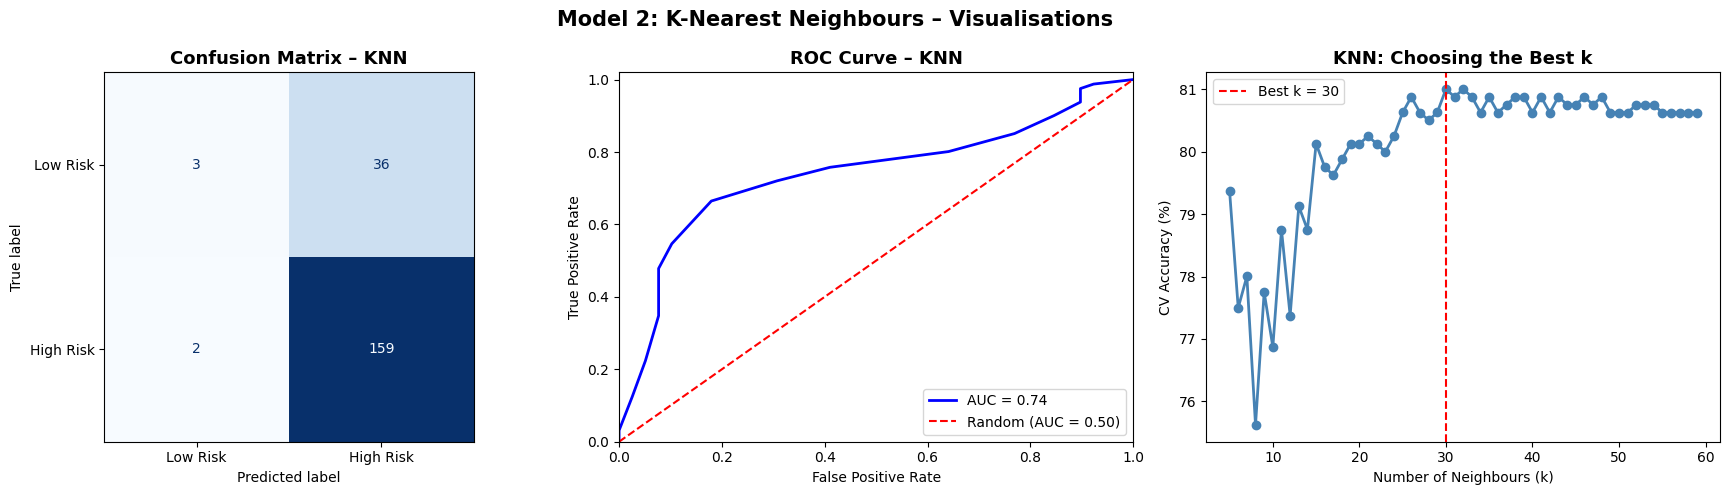

💾 Saved → model2_knn.png


In [44]:
from sklearn.neighbors import KNeighborsClassifier

# Find best k using cross-validation accuracy
k_range   = range(5, 60)
k_scores  = []
from sklearn.model_selection import cross_val_score
for k in k_range:
    knn_cv    = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn_cv, X_train_sc, y_train, cv=6, scoring='accuracy') 
    k_scores.append(cv_scores.mean())
best_k = k_range[k_scores.index(max(k_scores))]
print(f"✅ Best k found via CV: k = {best_k}  (cv accuracy = {max(k_scores)*100:.2f}%)")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_sc, y_train)
knn_pred  = knn_model.predict(X_test_sc)
# Output: [0, 1, 0, 1, 1, 0 ...]   ← hard labels, already decided

knn_prob  = knn_model.predict_proba(X_test_sc)[:, 1]
# Output: [0.22, 0.78, 0.11, 0.89, 0.67, 0.33 ...]   ← probability of being High Risk

knn_acc = print_metrics("KNN", y_test, knn_pred)

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model 2: K-Nearest Neighbours – Visualisations", fontsize=15, fontweight='bold')

# 2-A  Confusion Matrix
plot_confusion_matrix(y_test, knn_pred, "KNN", ax=axes[0])

# 2-B  ROC Curve
plot_roc_curve(y_test, knn_prob, "KNN", ax=axes[1])
# knn_pred gives you a label — knn_prob gives you a confidence score
# # With knn_pred → only ONE point possible
# roc_curve(y_test, knn_pred)    # gives ~3 points, degenerate "curve"
# # With knn_prob → full smooth curve across all thresholds
# roc_curve(y_test, knn_prob)    # gives N points → real ROC curve

# 2-C  K vs Accuracy plot
axes[2].plot(list(k_range), [s * 100 for s in k_scores], marker='o', color='steelblue', lw=2)
axes[2].axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
axes[2].set_xlabel('Number of Neighbours (k)')
axes[2].set_ylabel('CV Accuracy (%)')
axes[2].set_title('KNN: Choosing the Best k', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('model2_knn.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved → model2_knn.png")

plot_confusion_matrix(y_test, knn_pred, "KNN", ax=axes[0])

# MODEL 3 ▸ DECISION TREE CLASSIFIER


📊 Decision Tree
   Accuracy : 70.00%
              precision    recall  f1-score   support

    Low Risk      0.373     0.795     0.508        39
   High Risk      0.932     0.677     0.784       161

    accuracy                          0.700       200
   macro avg      0.653     0.736     0.646       200
weighted avg      0.823     0.700     0.730       200



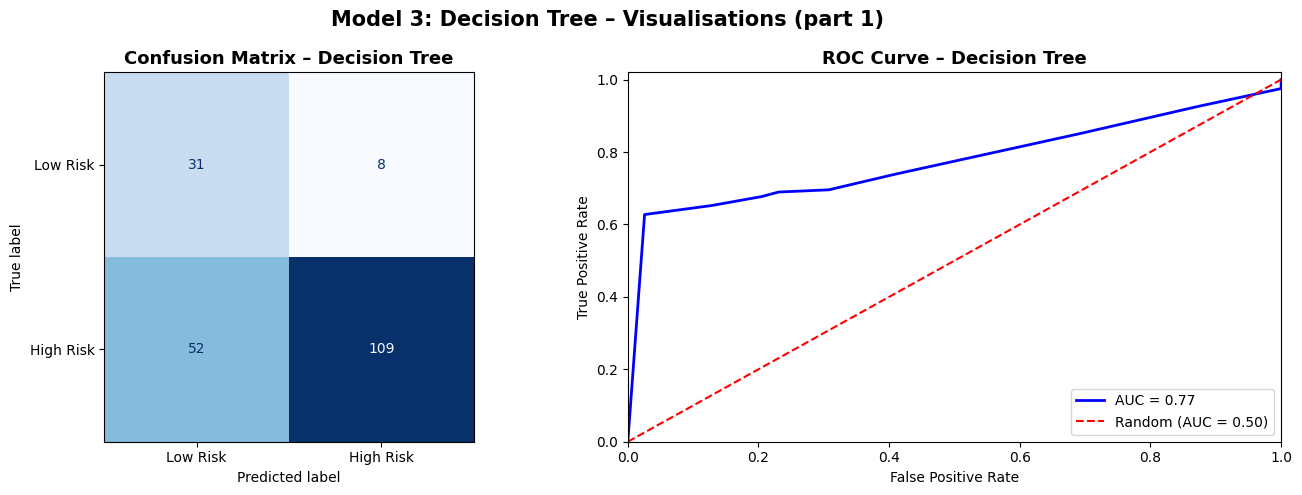

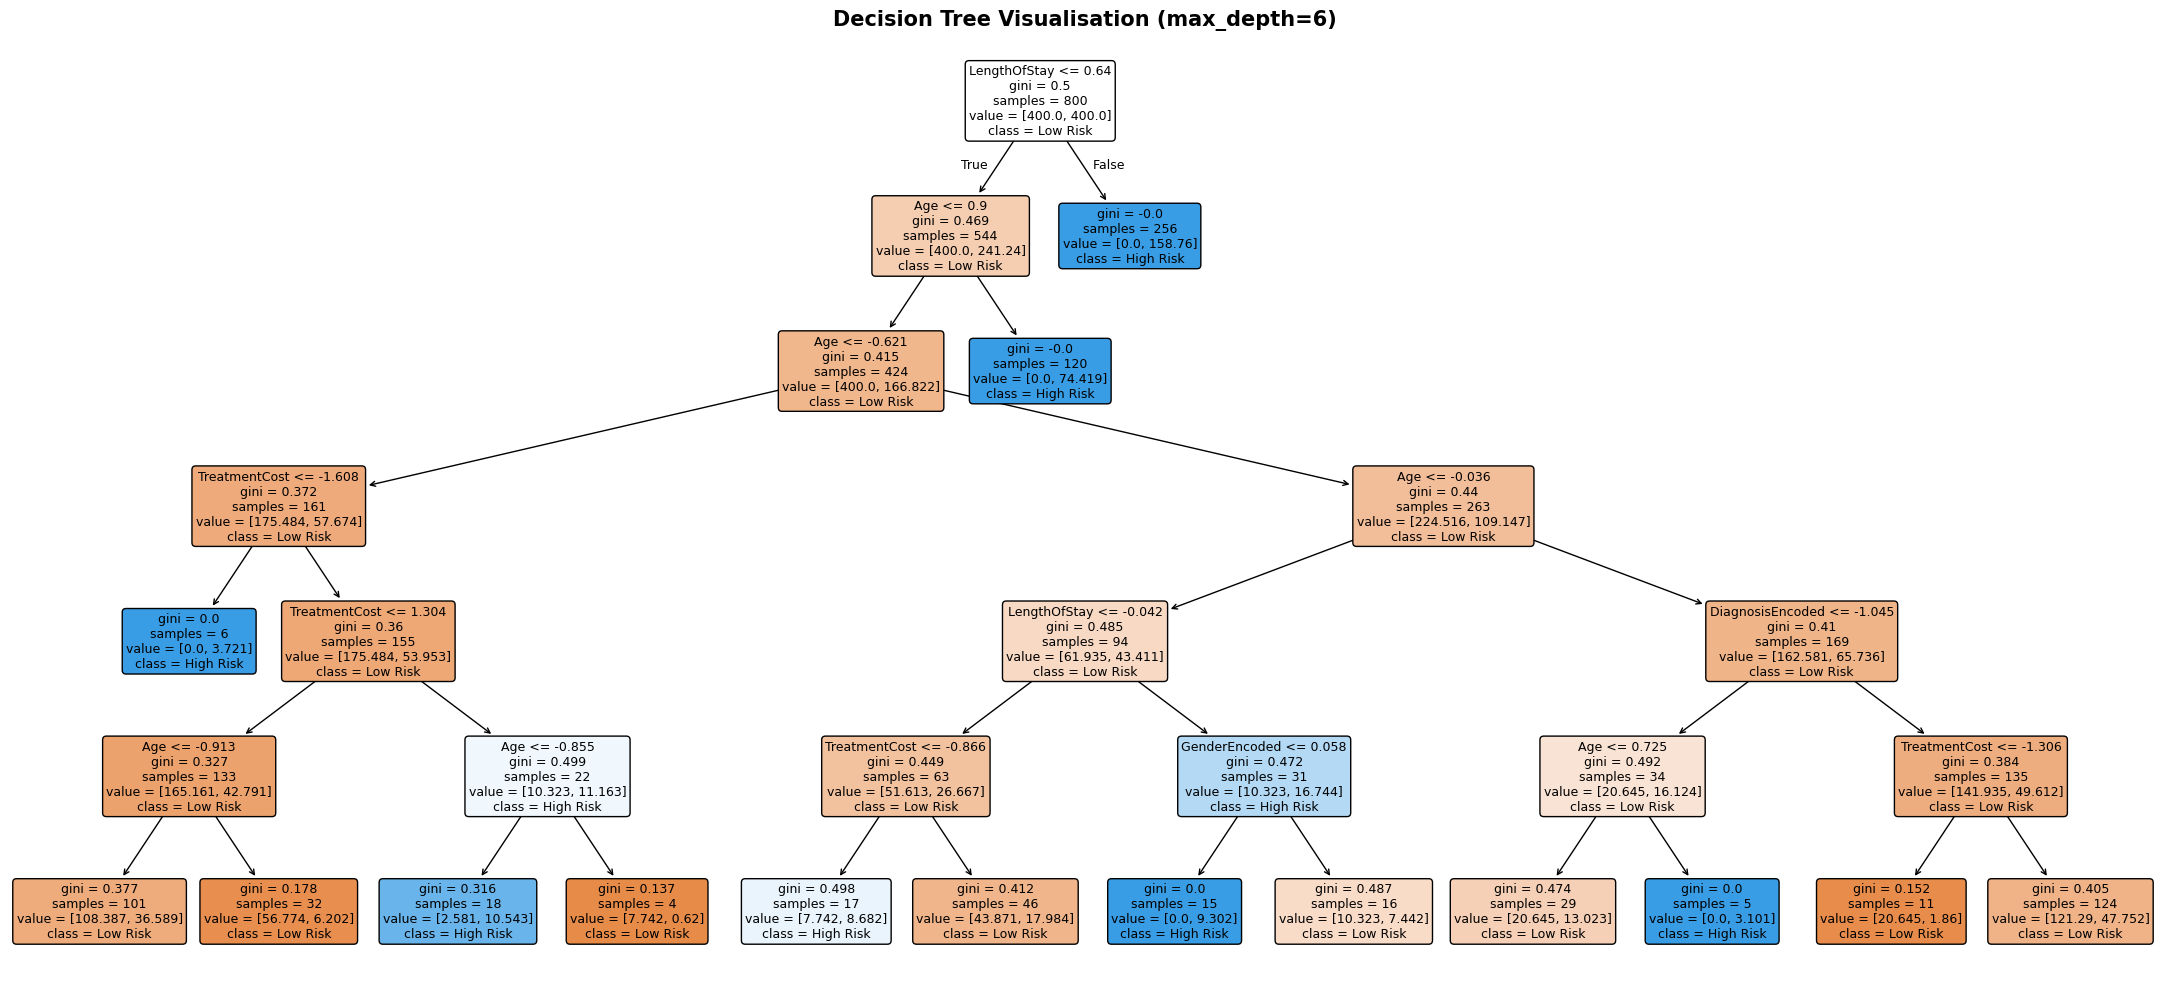

💾 Saved → model3_decision_tree_metrics.png  &  model3_decision_tree_viz.png


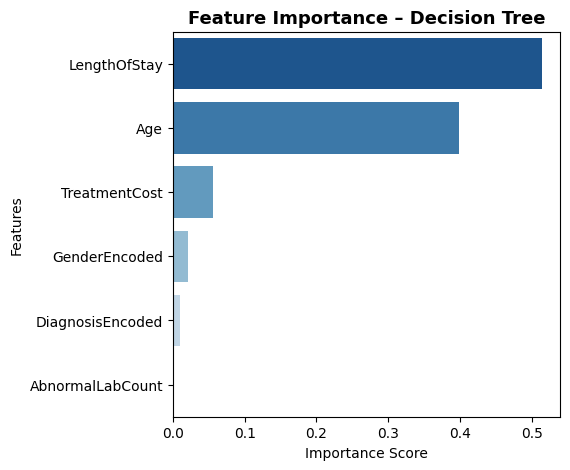

In [45]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(
    max_depth=6,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train_sc, y_train)
dt_pred  = dt_model.predict(X_test_sc)
dt_prob  = dt_model.predict_proba(X_test_sc)[:, 1]

dt_acc = print_metrics("Decision Tree", y_test, dt_pred)

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model 3: Decision Tree – Visualisations (part 1)", fontsize=15, fontweight='bold')

# 3-A  Confusion Matrix
plot_confusion_matrix(y_test, dt_pred, "Decision Tree", ax=axes[0])

# 3-B  ROC Curve
plot_roc_curve(y_test, dt_prob, "Decision Tree", ax=axes[1])

plt.tight_layout()
plt.savefig('model3_decision_tree_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# 3-C  Tree visualisation  (signature from ML_Learning.ipynb)
fig2, ax2 = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=FEATURES,
    class_names=['Low Risk', 'High Risk'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax2
)
ax2.set_title("Decision Tree Visualisation (max_depth=6)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model3_decision_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()

# 3-D  Feature Importance  (signature plot from ML_Learning.ipynb)
fig2, ax3 = plt.subplots(figsize=(5, 5))
importances  = dt_model.feature_importances_
feature_imp  = pd.Series(importances, index=FEATURES).sort_values(ascending=False)
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax3, palette='Blues_r')
ax3.set_title("Feature Importance – Decision Tree", fontsize=13, fontweight='bold')
ax3.set_xlabel("Importance Score")
ax3.set_ylabel("Features")



print("💾 Saved → model3_decision_tree_metrics.png  &  model3_decision_tree_viz.png")

# MODEL 4 ▸ NAIVE BAYES (Gaussian NB)


📊 Naive Bayes
   Accuracy : 77.50%
              precision    recall  f1-score   support

    Low Risk      0.393     0.282     0.328        39
   High Risk      0.837     0.894     0.865       161

    accuracy                          0.775       200
   macro avg      0.615     0.588     0.597       200
weighted avg      0.751     0.775     0.760       200



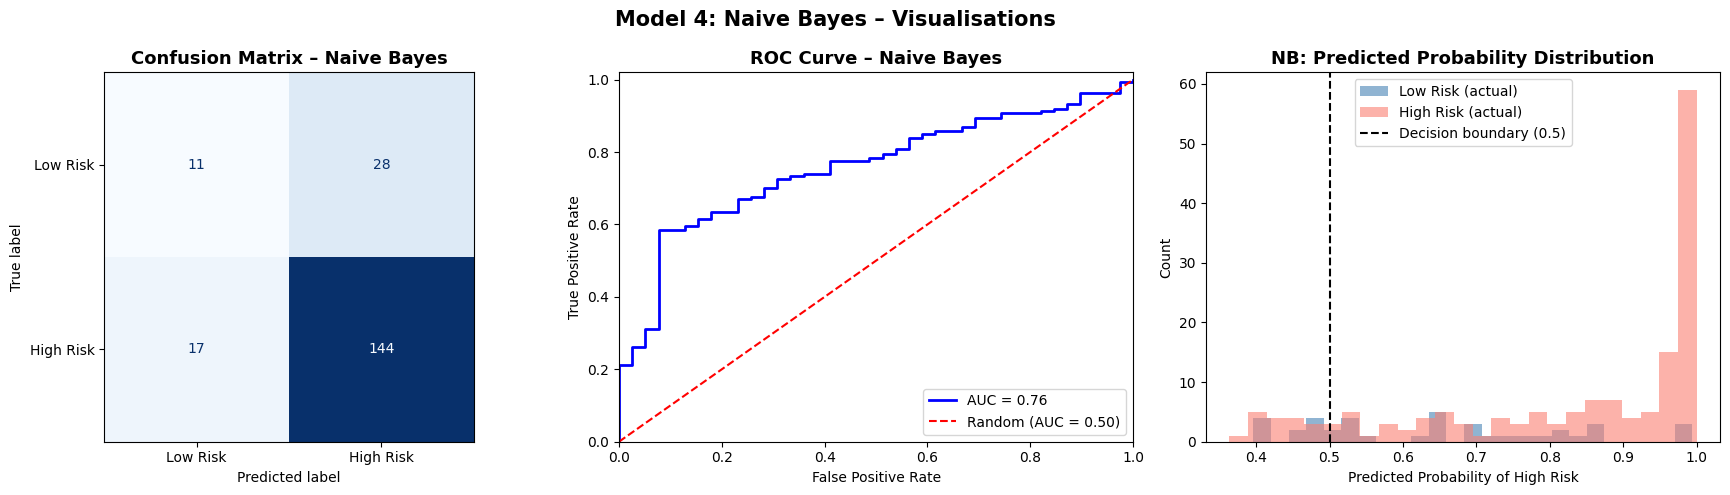

💾 Saved → model4_naive_bayes.png


In [46]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train)
nb_pred  = nb_model.predict(X_test_sc)
nb_prob  = nb_model.predict_proba(X_test_sc)[:, 1]

nb_acc = print_metrics("Naive Bayes", y_test, nb_pred)

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model 4: Naive Bayes – Visualisations", fontsize=15, fontweight='bold')

# 4-A  Confusion Matrix
plot_confusion_matrix(y_test, nb_pred, "Naive Bayes", ax=axes[0])

# 4-B  ROC Curve
plot_roc_curve(y_test, nb_prob, "Naive Bayes", ax=axes[1])

# 4-C  Predicted-Probability Distribution
axes[2].hist(nb_prob[y_test == 0], bins=25, alpha=0.6, color='steelblue', label='Low Risk (actual)')
axes[2].hist(nb_prob[y_test == 1], bins=25, alpha=0.6, color='salmon',    label='High Risk (actual)')
axes[2].axvline(0.5, color='black', linestyle='--', label='Decision boundary (0.5)')
axes[2].set_xlabel('Predicted Probability of High Risk')
axes[2].set_ylabel('Count')
axes[2].set_title('NB: Predicted Probability Distribution', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('model4_naive_bayes.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved → model4_naive_bayes.png")


# SECTION 4 ▸ COMBINED MODEL COMPARISON

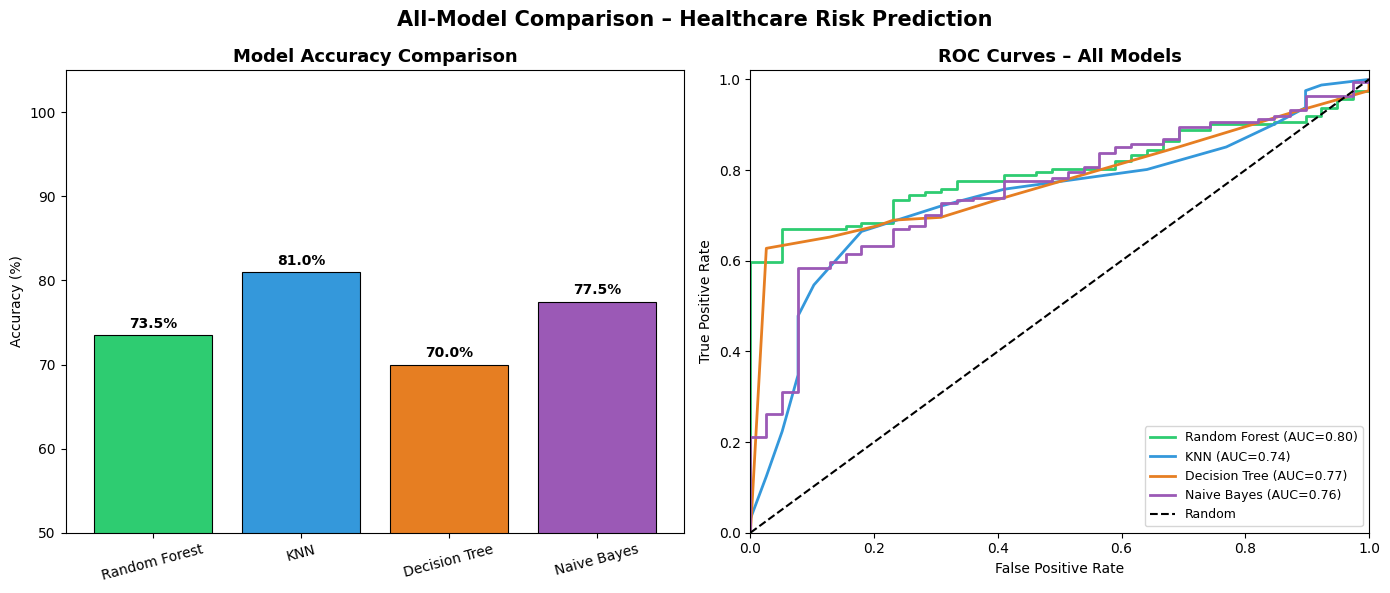

💾 Saved → model_comparison.png

📋 Final Summary Table
────────────────────────────────────────
Model                  Accuracy
────────────────────────────────────────
KNN                      81.00%
Naive Bayes              77.50%
Random Forest            73.50%
Decision Tree            70.00%
────────────────────────────────────────

🏆 Best Model: KNN (81.00%)


In [47]:
model_names = ['Random Forest', 'KNN', 'Decision Tree', 'Naive Bayes']
accuracies  = [rf_acc, knn_acc, dt_acc, nb_acc]

# --- Accuracy Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("All-Model Comparison – Healthcare Risk Prediction",
             fontsize=15, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']
bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_ylim([50, 105])
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

# --- Overlaid ROC Curves ---
model_probs = [rf_prob, knn_prob, dt_prob, nb_prob]
for name, probs, color in zip(model_names, model_probs, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})', color=color, lw=2)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves – All Models', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved → model_comparison.png")

# --- Summary Table ---
print("\n📋 Final Summary Table")
print("─" * 40)
print(f"{'Model':<20} {'Accuracy':>10}")
print("─" * 40)
for name, acc in sorted(zip(model_names, accuracies), key=lambda x: -x[1]):
    print(f"{name:<20} {acc:>9.2f}%")
print("─" * 40)
best_model = model_names[accuracies.index(max(accuracies))]
print(f"\n🏆 Best Model: {best_model} ({max(accuracies):.2f}%)")


# save the trained models - joblib.dump

In [48]:
import joblib
import os
from sklearn.metrics import roc_curve, auc

# ── diagnosis label encoder (needed by the app to encode user input) ──
diag_le = LabelEncoder()
diag_le.fit(patients['DiagnosisName'])

# ── metadata dict (all performance data the app dashboard needs) ──
def build_meta(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'accuracy': accuracy_score(y_true, y_pred) * 100,
        'cm':       confusion_matrix(y_true, y_pred).tolist(),
        'report':   classification_report(y_true, y_pred,
                        target_names=['Low Risk', 'High Risk'],
                        output_dict=True),
        'fpr':      fpr.tolist(),
        'tpr':      tpr.tolist(),
        'auc':      auc(fpr, tpr),
        'prob':     y_prob.tolist(),
    }

metadata = {
    'Random Forest': build_meta(y_test, rf_pred, rf_prob),
    'KNN':           build_meta(y_test, knn_pred, knn_prob),
    'Decision Tree': build_meta(y_test, dt_pred,  dt_prob),
    'Naive Bayes':   build_meta(y_test, nb_pred,  nb_prob),
    # extras needed by the app
    'y_test':            y_test.tolist(),
    'features':          FEATURES,
    'diagnosis_classes': list(diag_le.classes_),
    'best_k':            best_k,
    'k_range':           list(k_range),
    'k_scores':          k_scores,
    'rf_importances':    rf_model.feature_importances_.tolist(),
    'nb_prob':           nb_prob.tolist(),
}

print("✅ metadata and diag_le ready")

✅ metadata and diag_le ready


In [49]:
import joblib
import os

# Save all 4 trained models
os.makedirs('models', exist_ok=True)

joblib.dump(rf_model,  'models/rf_model.pkl')
joblib.dump(knn_model, 'models/knn_model.pkl')
joblib.dump(dt_model,  'models/dt_model.pkl')
joblib.dump(nb_model,  'models/nb_model.pkl')

# Save scaler and label encoder (needed for prediction in the app)
joblib.dump(scaler,  'models/scaler.pkl')
joblib.dump(diag_le, 'models/label_encoder_diagnosis.pkl')

# Save metadata (accuracy, AUC, confusion matrix etc. for the dashboard tabs)
joblib.dump(metadata, 'models/model_metadata.pkl')

print("✅ All models saved to models/ folder")
print("   Now run:  streamlit run risk_model2_app.py")

✅ All models saved to models/ folder
   Now run:  streamlit run risk_model2_app.py
